### ANALYSING ALIGNMENT OF TWO VECTORS USING DYNAMIC TIME WARPING (DTW)

In [17]:
#(a) plotting both vectors to visualise their patterns
#importing dependencies
import numpy as np
import matplotlib.pyplot as plt

#defining the vectors
vector1 = np.array([2, 3, 4, 6, 8, 7, 6, 5, 4, 3, 2])
vector2 = np.array([2, 4, 6, 7, 7, 6, 5, 5, 4, 3, 2, 2, 1])

#loading .wav files and extracting MFCC features
import librosa

def load_wav_mfcc(file_path):
    """Load .wav file and extract MFCC features"""
    y, sr = librosa.load(file_path)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    # Normalize to reasonable scale
    mfcc = (mfcc - np.mean(mfcc)) / np.std(mfcc)
    return mfcc.T  # Return as time x features

#load the .wav files
try:
    audio1_features = load_wav_mfcc('signal1_hello.wav')
    audio2_features = load_wav_mfcc('signal2_hello.wav')
    print(f"Audio 1 shape: {audio1_features.shape}")
    print(f"Audio 2 shape: {audio2_features.shape}")
    
    #use audio features instead of vectors for DTW
    vector1 = audio1_features
    vector2 = audio2_features
    print("Using audio MFCC features for DTW analysis")
except FileNotFoundError:
    print("Audio files not found, using original vectors")
except ImportError:
    print("librosa not installed, using original vectors")

Audio 1 shape: (87, 13)
Audio 2 shape: (87, 13)
Using audio MFCC features for DTW analysis


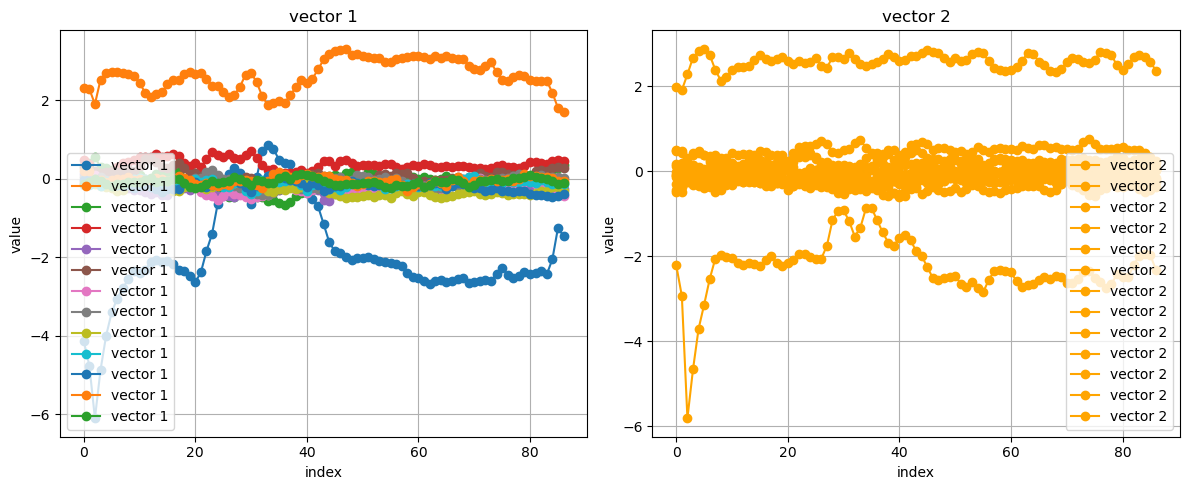

In [18]:
#plotting both signals to visualise their patterns
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(vector1, marker='o', label='vector 1')
plt.title('vector 1')
plt.xlabel('index')
plt.ylabel('value')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(vector2, marker='o', color='orange', label='vector 2')
plt.title('vector 2')
plt.xlabel('index')
plt.ylabel('value')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
#(b) implementing dynamic time warping (DTW) algorithm
def dtw(vector1, vector2):
    n = len(vector1)
    m = len(vector2)
    dtw_matrix = np.full((n+1, m+1), np.inf)
    dtw_matrix[0,0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            #handle both scalar and vector features
            if vector1.ndim == 1:  #scalar values
                cost = abs(vector1[i-1] - vector2[j-1])
            else:  #MFCC features (vectors)
                cost = np.linalg.norm(vector1[i-1] - vector2[j-1])
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i-1, j],
                dtw_matrix[i, j-1],
                dtw_matrix[i-1, j-1]
            )
    return dtw_matrix

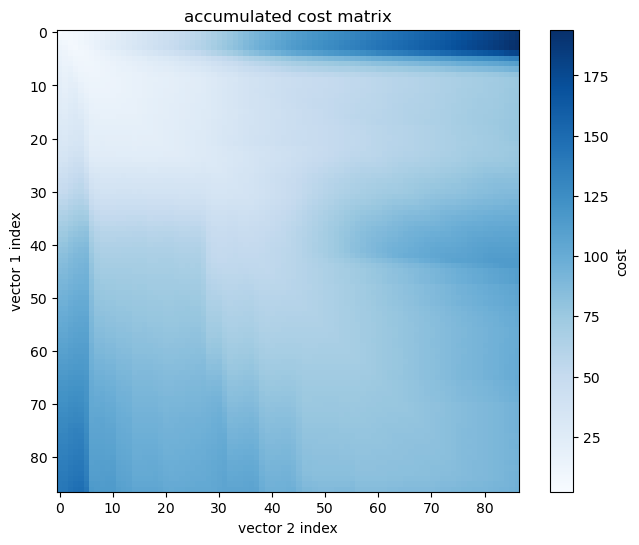

In [ ]:
#(c) computing the accumulated cost matrix using the DTW algorithm
dtw_matrix = dtw(vector1, vector2)

#visualising the accumulated cost matrix
plt.figure(figsize=(8,6))
plt.imshow(dtw_matrix[1:, 1:], interpolation='nearest', cmap='Blues')
plt.title('accumulated cost matrix')
plt.xlabel('vector 2 index')
plt.ylabel('vector 1 index')
plt.colorbar(label='cost')
plt.show()

In [21]:
#(d) finding and visualising the warping path
def dtw_path(dtw_matrix):
    i, j = np.array(dtw_matrix.shape) - 1
    path = [(i-1, j-1)]
    while (i > 1) or (j > 1):
        directions = [(i-1, j-1), (i-1, j), (i, j-1)]
        costs = [dtw_matrix[d] for d in directions]
        min_cost_index = np.argmin(costs)
        i, j = directions[min_cost_index]
        path.append((i-1, j-1))
    path.reverse()
    return path

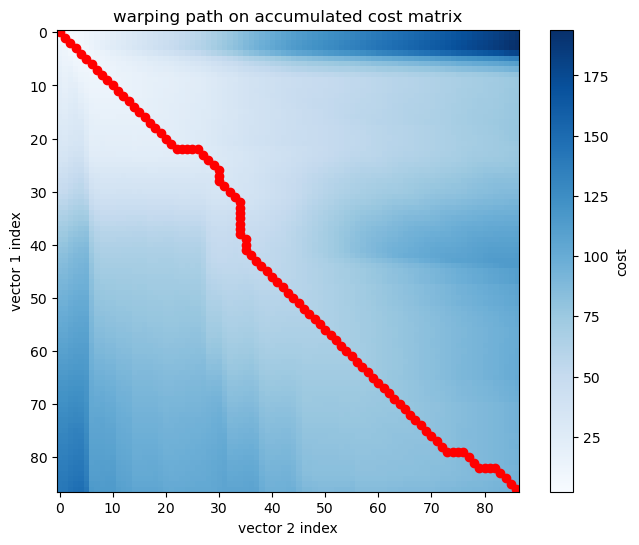

In [22]:
#computing the warping path
path = dtw_path(dtw_matrix)

#visualising the warping path on the accumulated cost matrix
path_x, path_y = zip(*path)

plt.figure(figsize=(8, 6))
plt.imshow(dtw_matrix[1:,1:], interpolation='nearest', cmap='Blues')
plt.plot(path_y, path_x, '-o', color='red')
plt.title('warping path on accumulated cost matrix')
plt.xlabel('vector 2 index')
plt.ylabel('vector 1 index')
plt.colorbar(label='cost')
plt.show()


In [23]:
#calculating DTW distance between the vectors
dtw_distance = dtw_matrix[-1, -1]
print(f"dtw distance between vector 1 and vector 2: {dtw_distance:.2f}")

dtw distance between vector 1 and vector 2: 95.09
